# Kinetic-EFIT End-to-End Chain

Drives the full VEST kinetic pipeline over the consolidated `vaft.code.kineticEfit`
API for a single equilibrium slice:

1. **Load** a magnetic-EFIT `gfile` + raw Thomson / charge-exchange diagnostics into an ODS.
2. **`build_kinetic_core_profiles`** — psi_N mapping + `ne`/`Te`/`Ti`/`Vtor` fits + `core_profiles`
   with `pressure_thermal`, `p = e·nₑ·(Tₑ+Tᵢ)` (pure ODS→ODS).
3. **`kinetic_pressure_points`** — the `RPRESS`/`PRESSR`/`SIGPRE`/`FWTPRE` constraint points (raw-6pt).
4. **`run_kinetic_efit`** — kinetic-pressure EFIT with a `PLASMA`-scale sweep (needs `$EFIT` + a base kfile).
5. **`refine_equilibrium`** — CHEASE refinement of the best equilibrium (needs `$CHEASE`).
6. **Compare** the magnetic, kinetic, and CHEASE-refined equilibria.

This notebook runs on the **physically-paired VEST shot 48224 @ 300 ms** dataset packaged
under `vaft/data/kineticEfit/` (equilibrium `g048224.00300`, Thomson `NeTe_48224.mat`,
ion Doppler `IDS_48224.mat` — all the same shot and time). Each external-code stage
degrades gracefully: if `$EFIT` / a base kfile / `$CHEASE` is unset the notebook prints a
clear `skipped: …` message and the remaining cells stay executable.

Override `VAFT_KINETIC_DATA_ROOT` to point at another paired dataset; set `$EFIT` +
`$VAFT_KINETIC_BASE_KFILE` and `$CHEASE` to run the kinetic-EFIT and CHEASE stages.

In [ ]:
import os
from pathlib import Path
import tempfile

import matplotlib.pyplot as plt
import numpy as np

import vaft
from vaft.data.resources import data_path
from vaft.data import read_geqdsk
from vaft.code.kineticEfit import (
    build_kinetic_core_profiles,
    kinetic_pressure_points,
    KineticEFITConfig,
    prepare_kinetic_efit_inputs,
    run_kinetic_efit,
)
from vaft.code.chease import CHEASEConfig, find_chease_executable, refine_equilibrium

vaft.apply_omfit_compat_patches()
from omfit_classes.omfit_eqdsk import OMFITgeqdsk

# --- physically-paired VEST shot 48224 @ 300 ms (vaft/data/kineticEfit/) ---
SHOT    = 48224
TIME_MS = 300.0
DATA_ROOT = Path(os.environ.get("VAFT_KINETIC_DATA_ROOT", str(data_path() / "kineticEfit")))
GFILE    = DATA_ROOT / f"g0{SHOT}.{int(TIME_MS):05d}"
TS_MAT   = DATA_ROOT / f"NeTe_{SHOT}.mat"
ION_MAT  = DATA_ROOT / f"IDS_{SHOT}.mat"
ION_OPT  = "ids"
TIME_TOL_MS = 3.0   # small: gfile / Thomson / ion diagnostics are all this same 300 ms slice
WORKROOT = Path(tempfile.mkdtemp(prefix="vaft-kinetic-"))

# Binaries / base kfile resolved from env vars (graceful skip when unset).
EFIT_EXE   = os.environ.get("EFIT")                       # KineticEFITConfig also falls back to $EFIT
# Base magnetic kfile the pressure block patches; default to the VEST filedb path.
_filedb_kfile = Path(f"/srv/vest.filedb/public/{SHOT}/efit/kfile/k0{SHOT}.{int(TIME_MS):05d}")
BASE_KFILE = os.environ.get("VAFT_KINETIC_BASE_KFILE") or (str(_filedb_kfile) if _filedb_kfile.exists() else None)
_chease_found = find_chease_executable()
CHEASE_EXE = os.environ.get("CHEASE") or (str(_chease_found) if _chease_found else None)

print(f"Data root  : {DATA_ROOT}")
print(f"Slice      : shot {SHOT} @ {TIME_MS:.0f} ms  (eq {GFILE.name} + TS/ion {SHOT})")
print(f"Work dir   : {WORKROOT}")
print(f"$EFIT      : {EFIT_EXE or '(unset -> kinetic EFIT skipped)'}")
print(f"base kfile : {BASE_KFILE or '(unset -> kinetic EFIT skipped)'}")
print(f"CHEASE exe : {CHEASE_EXE or '(unset -> CHEASE refine skipped)'}")

Data root  : /home/user1/h5pyd/vaft/vaft/data/kineticEfit
Slice      : shot 48224 @ 300 ms  (eq g048224.00300 + TS/ion 48224)
Work dir   : /tmp/vaft-kinetic-xot3fsll
$EFIT      : /home/user1/work/efit-new2/build/efit/efit
base kfile : /srv/vest.filedb/public/48224/efit/kfile/k048224.00300
CHEASE exe : /home/user1/work/chease_1/chease


## 1. Load The Magnetic Equilibrium And Raw Kinetic Diagnostics

The magnetic-EFIT `gfile` seeds the ODS `equilibrium`; Thomson scattering supplies
`nₑ`/`Tₑ` and the ion Doppler (IDS) supplies `Tᵢ`/`Vtor`. I/O only — no profile physics yet.

In [ ]:
geq = OMFITgeqdsk(str(GFILE))
geq["fluxSurfaces"].load()

ods = geq.to_omas()
ods["equilibrium.ids_properties.homogeneous_time"] = 1
vaft.machine_mapping.dataset_description(
    ods, source=SHOT,
    options={"source_type": "shot",
             "description": f"VEST kinetic chain shot {SHOT} @ {TIME_MS:.0f} ms (TS + ion Doppler)"},
)

# electrons: Thomson scattering; ions: IDS -> charge_exchange (same shot 48224)
vaft.machine_mapping.thomson_scattering(ods, SHOT, str(TS_MAT))
vaft.machine_mapping.charge_exchange(ods, shotnumber=SHOT, options=ION_OPT, mat_file=str(ION_MAT))

print(f"gfile        : {GFILE.name}")
print(f"Ip (magnetic): {float(geq['CURRENT']):.6e} A")
print(f"B0           : {float(geq['BCENTR']):.4f} T")
print(f"TS channels  : {len(ods['thomson_scattering.channel'])}")
print(f"CX channels  : {len(ods['charge_exchange.channel'])}")

gfile        : g048224.00300
Ip (magnetic): 1.431674e+05 A
B0           : 0.1509 T
TS channels  : 7
CX channels  : 40


## 2. Build The Kinetic Core Profiles

`build_kinetic_core_profiles` is a pure ODS→ODS orchestration of the `vaft.process.profile`
chain: it maps TS and CX onto the equilibrium `psi_N`, fits `nₑ`/`Tₑ` (TS) and `Tᵢ`/`Vtor`
(ion diagnostic), and writes `core_profiles.profiles_1d[0]` including `pressure_thermal`
(`p = e·nₑ·(Tₑ+Tᵢ)`, `n_i ≈ n_e`). `time_tolerance_ms` is widened here because the demo
pairs a 320 ms equilibrium with 300 ms diagnostics.

In [ ]:
ods = build_kinetic_core_profiles(
    ods, geq, TIME_MS,
    te_mode="polynomial",
    ne_mode="free_exponential",
    ti_mode="polynomial",
    vtor_mode="polynomial",
    ion_index=0,
    time_tolerance_ms=TIME_TOL_MS,
)

cp = "core_profiles.profiles_1d.0"
rho  = np.asarray(ods[f"{cp}.grid.rho_tor_norm"])
ne   = np.asarray(ods[f"{cp}.electrons.density"])
te   = np.asarray(ods[f"{cp}.electrons.temperature"])
ti   = np.asarray(ods[f"{cp}.ion.0.temperature"])
vtor = np.asarray(ods[f"{cp}.ion.0.velocity.toroidal"])
pth  = np.asarray(ods[f"{cp}.pressure_thermal"])

print(f"grid points : {rho.size}")
print(f"ne0         : {ne[0]:.3e} m^-3")
print(f"Te0         : {te[0]:.1f} eV")
print(f"Ti0         : {ti[0]:.1f} eV")
print(f"Vtor0       : {vtor[0]:.3e} m/s")
print(f"p_th0       : {pth[0]:.1f} Pa")

[INFO] dropped 2 invalid TS channel(s) at 300.000 ms (non-finite value/sigma or unmapped position)
[INFO] dropped 7 invalid CES T_i channel(s) at 300.000 ms
[INFO] dropped 7 invalid CES V_tor channel(s) at 300.000 ms
[UPDATED] core_profile at 300.000 ms (index 0)
grid points : 129
ne0         : 9.916e+18 m^-3
Te0         : 64.8 eV
Ti0         : 14.3 eV
Vtor0       : -3.567e+04 m/s
p_th0       : 125.7 Pa


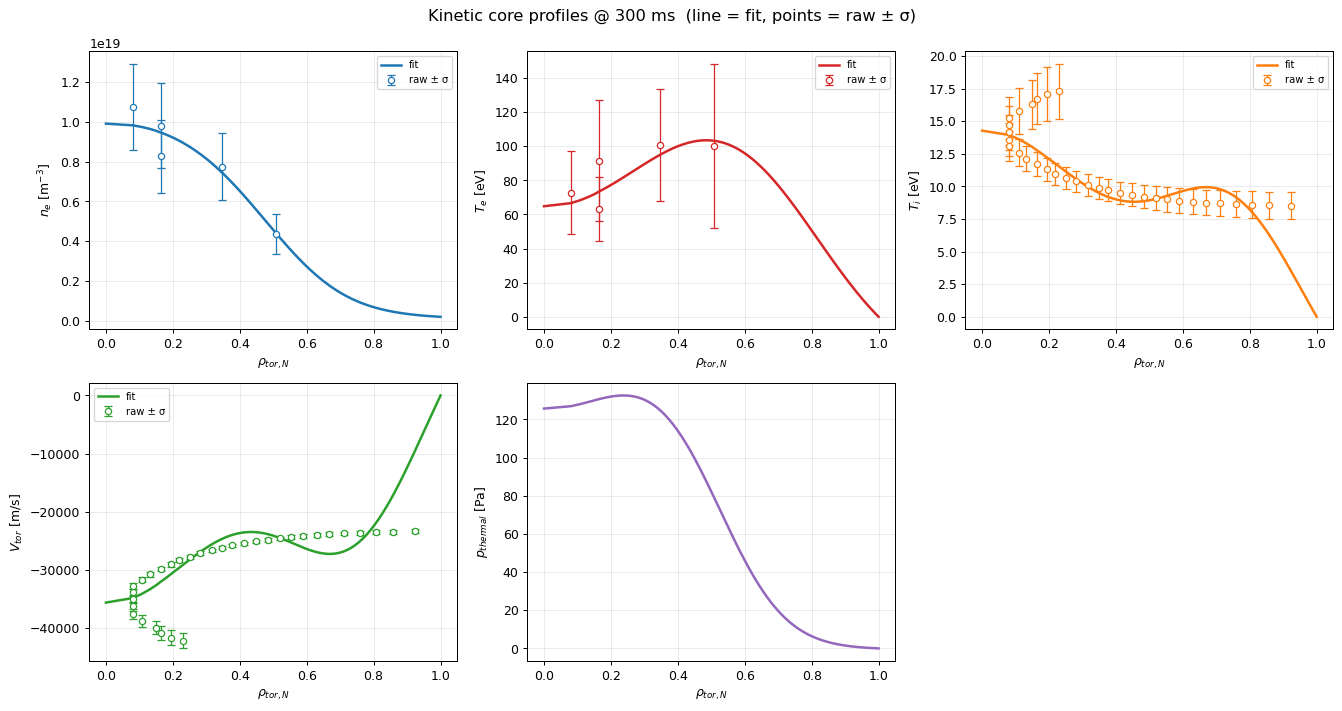

In [ ]:
# raw measured points WITH error bars, read straight from the diagnostic channels
# and mapped psi_N -> rho_tor on the equilibrium grid.
psi_grid = np.asarray(ods[f"{cp}.grid.psi"], dtype=float)
psin_grid = (psi_grid - psi_grid[0]) / (psi_grid[-1] - psi_grid[0])
def _to_rhotor(psiN):
    return np.interp(np.clip(np.asarray(psiN, dtype=float), 0, 1), psin_grid, rho)

# Thomson channels -> (rho_tor, value, error) at this time
ts_psiN = np.asarray(vaft.process.equilibrium_mapping_thomson_scattering(ods, geq), dtype=float)
it = int(np.argmin(np.abs(np.asarray(ods["thomson_scattering.time"], dtype=float) - TIME_MS / 1e3)))
n_ts = len(ods["thomson_scattering.channel"])
def _ts(field):
    v = np.array([float(np.asarray(ods[f"thomson_scattering.channel.{i}.{field}.data"], dtype=float)[it]) for i in range(n_ts)])
    e = np.array([float(np.asarray(ods[f"thomson_scattering.channel.{i}.{field}.data_error_upper"], dtype=float)[it]) for i in range(n_ts)])
    return v, e
ne_v, ne_e = _ts("n_e"); te_v, te_e = _ts("t_e")
ts_rho = _to_rhotor(ts_psiN)

# charge_exchange channels -> (rho_tor, value, error) at this time
cx_psiN = np.asarray(vaft.process.equilibrium_mapping_charge_exchange(ods, geq), dtype=float)
jt = int(np.argmin(np.abs(np.asarray(ods["charge_exchange.time"], dtype=float) - TIME_MS / 1e3)))
n_cx = len(ods["charge_exchange.channel"])
def _cx(field):
    v, e = [], []
    for i in range(n_cx):
        ion = ods[f"charge_exchange.channel.{i}.ion.0.{field}"]
        v.append(float(np.asarray(ion["data"], dtype=float)[jt]))
        try:
            e.append(float(np.asarray(ion["data_error_upper"], dtype=float)[jt]))
        except Exception:
            e.append(np.nan)
    return np.array(v), np.array(e)
ti_v, ti_e = _cx("t_i"); vtor_v, vtor_e = _cx("velocity_tor")
cx_rho = _to_rhotor(cx_psiN)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
panels = [
    (ne,   ts_rho, ne_v,   ne_e,   r"$n_e$ [m$^{-3}$]",   "tab:blue"),
    (te,   ts_rho, te_v,   te_e,   r"$T_e$ [eV]",         "tab:red"),
    (ti,   cx_rho, ti_v,   ti_e,   r"$T_i$ [eV]",         "tab:orange"),
    (vtor, cx_rho, vtor_v, vtor_e, r"$V_{tor}$ [m/s]",    "tab:green"),
    (pth,  None,   None,   None,   r"$p_{thermal}$ [Pa]", "tab:purple"),
]
for ax, (y, rx, rv, re, ylabel, color) in zip(axes.flat, panels):
    ax.plot(rho, y, color=color, lw=2, label="fit")
    if rx is not None:
        m = np.isfinite(rx) & np.isfinite(rv)
        yerr = np.where(np.isfinite(re[m]), re[m], 0.0)
        ax.errorbar(rx[m], rv[m], yerr=yerr, fmt="o", color=color, mfc="white",
                    ms=5, capsize=3, elinewidth=1, label="raw ± σ")
        ax.legend(fontsize=8)
    ax.set_xlabel(r"$\rho_{tor,N}$")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
axes.flat[-1].axis("off")
fig.suptitle(f"Kinetic core profiles @ {TIME_MS:.0f} ms  (line = fit, points = raw ± σ)", fontsize=13)
fig.tight_layout()
plt.show()

## 3. Build The Kinetic-Pressure Constraint Points

`kinetic_pressure_points` turns the fitted profiles into the EFIT pressure constraint.
With `encoding='raw6'` it emits the 5 Thomson points at their real major radius `R>0` plus a
6th `psi_N=1, p=0` edge anchor (`RPRESS=-1.0`). Each carries `PRESSR = e·nₑ·(Tₑ+Tᵢ)` and the
propagated `SIGPRE`.

encoding : raw6  (6 points)
    RPRESS    PRESSR[Pa]    SIGPRE[Pa]    FWTPRE
    0.4750       113.593        38.647     1.000
    0.4250       140.937        50.484     1.000
    0.3700       133.347        55.510     1.000
    0.3100       136.328        50.486     1.000
    0.2550        76.455        38.108     1.000
   -1.0000         0.000         7.047     1.000


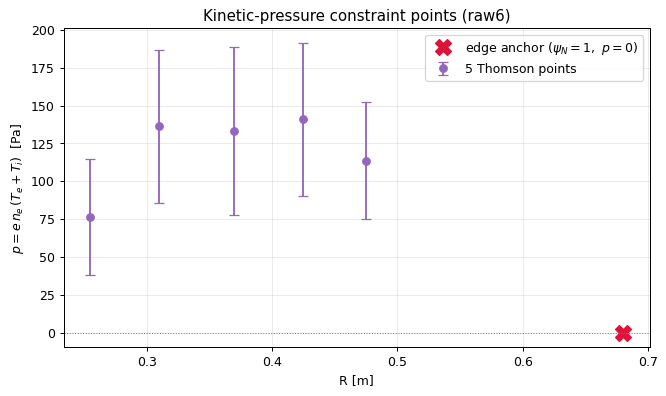

In [ ]:
points = kinetic_pressure_points(ods, TIME_MS, geq=geq, encoding="raw6")

print(f"encoding : raw6  ({len(points.rpress)} points)")
print(f"{'RPRESS':>10}{'PRESSR[Pa]':>14}{'SIGPRE[Pa]':>14}{'FWTPRE':>10}")
for i in range(len(points.rpress)):
    print(f"{points.rpress[i]:>10.4f}{points.pressr[i]:>14.3f}"
          f"{points.sigpre[i]:>14.3f}{points.fwtpre[i]:>10.3f}")

rp = np.asarray(points.rpress, dtype=float)
pr = np.asarray(points.pressr, dtype=float)
sg = np.asarray(points.sigpre, dtype=float)
real = rp > 0.0        # the 5 Thomson points at their real major radius R
anchor = ~real         # the synthetic RPRESS=-1.0 (psi_N=1) edge anchor, p=0

# place the psi_N=1 anchor at the outboard separatrix major radius so it shows on R
try:
    R_sep = float(np.max(np.asarray(geq["RBBBS"], dtype=float)))
except Exception:
    R_sep = float(rp[real].max())

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.errorbar(rp[real], pr[real], yerr=sg[real], fmt="o", color="tab:purple",
            capsize=4, label=f"{int(real.sum())} Thomson points")
ax.plot([R_sep] * int(anchor.sum()), pr[anchor], "X", color="crimson", ms=13,
        label=r"edge anchor ($\psi_N=1,\ p=0$)")
ax.axhline(0.0, color="grey", lw=0.8, ls=":")
ax.set_xlabel("R [m]")
ax.set_ylabel(r"$p = e\,n_e\,(T_e + T_i)$  [Pa]")
ax.set_title("Kinetic-pressure constraint points (raw6)")
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## 4. Run The Kinetic-Pressure EFIT

`run_kinetic_efit` injects the pressure constraint into the base magnetic kfile, runs EFIT
across the `PLASMA`-scale sweep, and keeps the largest scale that converges. It needs `$EFIT`
and a base magnetic kfile (`$VAFT_KINETIC_BASE_KFILE`) — the packaged sample has none, so this
cell prints a clear `skipped:` line unless both are provided on a real slice.

In [ ]:
efit_result = None
if not EFIT_EXE or not BASE_KFILE:
    print("skipped: set $EFIT and $VAFT_KINETIC_BASE_KFILE (a magnetic kfile) to run the "
          "kinetic-pressure EFIT. The packaged demo sample ships no base kfile.")
else:
    try:
        efit_config = KineticEFITConfig(
            executable=EFIT_EXE,
            workdir=str(WORKROOT / "kinetic_efit"),
            shot=SHOT,
            time_ms=TIME_MS,
            encoding="raw6",
            base_kfile=BASE_KFILE,
            timeout=600,
        )
        efit_inputs = prepare_kinetic_efit_inputs(ods, geq, efit_config)
        efit_result = run_kinetic_efit(efit_inputs, efit_config)
        if efit_result.status == "skipped":
            print(f"skipped: {efit_result.reason}")
        elif efit_result.converged:
            print(f"converged at PLASMA scale = {efit_result.scale}")
            print(f"gfile : {efit_result.gfile}")
        else:
            print(f"did not converge (status={efit_result.status}): {efit_result.reason}")
    except Exception as exc:
        print(f"skipped: kinetic EFIT raised {type(exc).__name__}: {exc}")

converged at PLASMA scale = 1.0
gfile : /tmp/vaft-kinetic-xot3fsll/kinetic_efit/s100/g048224.00300


## 5. Refine The Equilibrium With CHEASE

`refine_equilibrium` runs the CHEASE inverse solver (pure-python jsk95 parity) on the best
available equilibrium — the kinetic-EFIT `gfile` if that step converged, otherwise the magnetic
`gfile`. CHEASE is discovered from `$CHEASE` / `CHEASE_EXEC_DIR`; the cell prints a clear
`skipped:` line when no executable is found.

In [ ]:
if efit_result is not None and getattr(efit_result, "gfile", None):
    chease_source, src_label = efit_result.gfile, "kinetic-EFIT gfile"
else:
    chease_source, src_label = GFILE, "magnetic gfile (kinetic EFIT unavailable)"

chease_result = None
if not CHEASE_EXE:
    print("skipped: set $CHEASE (or CHEASE_EXEC_DIR) to run the CHEASE refinement.")
else:
    try:
        chease_config = CHEASEConfig(
            executable=str(CHEASE_EXE),
            workdir=str(WORKROOT / "chease"),
            create_plot=False,
            cleanup=False,
            timeout=350,
        )
        print(f"refining {src_label}: {Path(str(chease_source)).name}")
        chease_result = refine_equilibrium(str(chease_source), chease_config)
        if chease_result.ok and chease_result.refined_geqdsk:
            print(f"refined gfile : {chease_result.refined_geqdsk}")
            for key, value in (chease_result.comparison or {}).items():
                print(f"  {key}: {value:.6g}")
        else:
            print("CHEASE produced no refined GEQDSK in this environment.")
            tail = (chease_result.stderr or "").strip().splitlines()[-8:]
            if tail:
                print("\n".join(tail))
    except Exception as exc:
        print(f"skipped: CHEASE raised {type(exc).__name__}: {exc}")

refining kinetic-EFIT gfile: g048224.00300
refined gfile : /tmp/vaft-kinetic-xot3fsll/chease/EQDSK_COCOS_02.OUT
  q_rms_rel: 0.00940241
  pressure_rms_rel: 0.0515247
  pprime_rms_rel: 0.0210722
  ffprim_rms_rel: 0.0210442
  psi_axis_abs_diff: 0.00197778
  psi_boundary_abs_diff: 0.00181232
  boundary_r_rms: 0.42545
  boundary_z_rms: 0.0310922
  boundary_rz_rms: 0.426585
  boundary_points: 300


## 6. Compare Magnetic vs Kinetic vs CHEASE Equilibria

Overlay `q(ψ_N)`, `p(ψ_N)`, and the boundary for every equilibrium that is actually available.
With no binaries only the magnetic equilibrium is shown; `$EFIT`+base-kfile overlays the kinetic
reconstruction, and `$CHEASE` overlays the refined result.

Equilibria compared: ['Magnetic EFIT', 'Kinetic EFIT', 'CHEASE refined']

One-call equivalent of this whole notebook:
  from vaft.code.kineticEfit import run_kinetic_chain
  out = run_kinetic_chain(ods, geq, TIME_MS, efit_config=efit_config,
                          chease_config=chease_config)


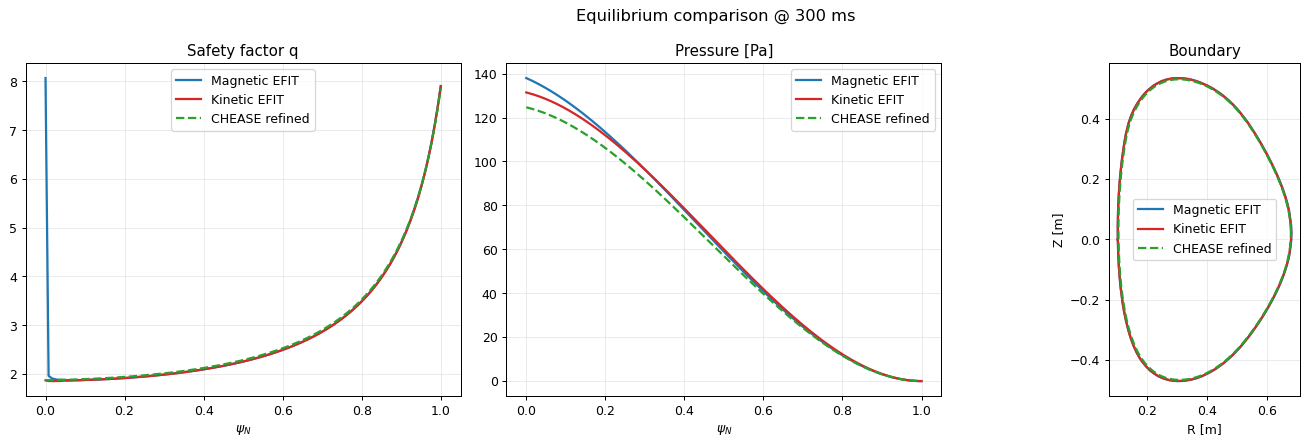

In [ ]:
def _try_read(path):
    try:
        return read_geqdsk(str(path)) if path else None
    except Exception:
        return None


eqs = [("Magnetic EFIT", GFILE, "tab:blue", "-")]
if efit_result is not None and getattr(efit_result, "gfile", None):
    eqs.append(("Kinetic EFIT", efit_result.gfile, "tab:red", "-"))
if chease_result is not None and getattr(chease_result, "refined_geqdsk", None):
    eqs.append(("CHEASE refined", chease_result.refined_geqdsk, "tab:green", "--"))

loaded = [(label, _try_read(path), color, ls) for label, path, color, ls in eqs]
loaded = [t for t in loaded if t[1] is not None]

fig, (ax_q, ax_p, ax_b) = plt.subplots(1, 3, figsize=(16, 5))
for label, g, color, ls in loaded:
    x = np.linspace(0.0, 1.0, int(g["NW"]))
    ax_q.plot(x, np.asarray(g["QPSI"], dtype=float), color=color, ls=ls, lw=1.8, label=label)
    ax_p.plot(x, np.asarray(g["PRES"], dtype=float), color=color, ls=ls, lw=1.8, label=label)
    rb = np.asarray(g.get("RBBBS", []), dtype=float)
    zb = np.asarray(g.get("ZBBBS", []), dtype=float)
    if rb.size and zb.size:
        n = min(rb.size, zb.size)
        ax_b.plot(rb[:n], zb[:n], color=color, ls=ls, lw=1.8, label=label)

ax_q.set_title("Safety factor q"); ax_q.set_xlabel(r"$\psi_N$"); ax_q.grid(True, alpha=0.25); ax_q.legend()
ax_p.set_title("Pressure [Pa]"); ax_p.set_xlabel(r"$\psi_N$"); ax_p.grid(True, alpha=0.25); ax_p.legend()
ax_b.set_title("Boundary"); ax_b.set_xlabel("R [m]"); ax_b.set_ylabel("Z [m]")
ax_b.set_aspect("equal", adjustable="box"); ax_b.grid(True, alpha=0.25); ax_b.legend()
fig.suptitle(f"Equilibrium comparison @ {TIME_MS:.0f} ms", fontsize=13)
fig.tight_layout()
plt.show()

print(f"Equilibria compared: {[label for label, *_ in loaded]}")
if len(loaded) == 1:
    print("Only the magnetic equilibrium is available - set $EFIT + $VAFT_KINETIC_BASE_KFILE "
          "and $CHEASE to populate the kinetic and refined overlays.")

print("\nOne-call equivalent of this whole notebook:")
print("  from vaft.code.kineticEfit import run_kinetic_chain")
print("  out = run_kinetic_chain(ods, geq, TIME_MS, efit_config=efit_config,")
print("                          chease_config=chease_config)")